# Anomaly Detection

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Isolation Forests

### a. Data Prep

In [16]:
df = pd.read_csv('../Data/entertainment_clean.csv')
df.head()

,name,books,tv_shows,video_games
0,Aaliyah,0.5,4.6,4.9
1,Abigail,0.0,4.5,4.8
2,Addison,0.5,4.5,5.0
3,Adeline,3.5,4.5,6.6
4,Alana,2.8,3.8,5.6


In [6]:
X = df.iloc[:, 1:]
X.head()

,books,tv_shows,video_games
0,0.5,4.6,4.9
1,0.0,4.5,4.8
2,0.5,4.5,5.0
3,3.5,4.5,6.6
4,2.8,3.8,5.6


In [7]:
X.shape

(150, 3)

### b. Fit an Isolation Forest Model

In [8]:
from sklearn.ensemble import IsolationForest

In [9]:
model = IsolationForest(contamination=0.02)

In [10]:
model.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.02
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,None
,verbose,0
,warm_start,False


In [26]:
df["anomaly_scores"] = model.decision_function(X)
df["anomaly"] = model.predict(X)

In [14]:
df["anomaly_scores"] = model.decision_function(X)
df.sort_values("anomaly_scores").head()

,name,books,tv_shows,video_games,anomaly_scores
110,Octavia,5.0,5.7,7.9,-0.033218
15,Avery,1.0,6.6,5.7,-0.023975
147,Zara,5.5,5.7,7.7,-0.004435
37,Elena,0.8,3.4,4.5,0.000091
29,Clementine,6.2,5.4,7.2,0.002801


In [15]:
df["anomaly"] = model.predict(X)
df.sort_values("anomaly_scores").head()

,name,books,tv_shows,video_games,anomaly_scores,anomaly
110,Octavia,5.0,5.7,7.9,-0.033218,-1
15,Avery,1.0,6.6,5.7,-0.023975,-1
147,Zara,5.5,5.7,7.7,-0.004435,-1
37,Elena,0.8,3.4,4.5,0.000091,1
29,Clementine,6.2,5.4,7.2,0.002801,1


### c. Visualize the Anomalies

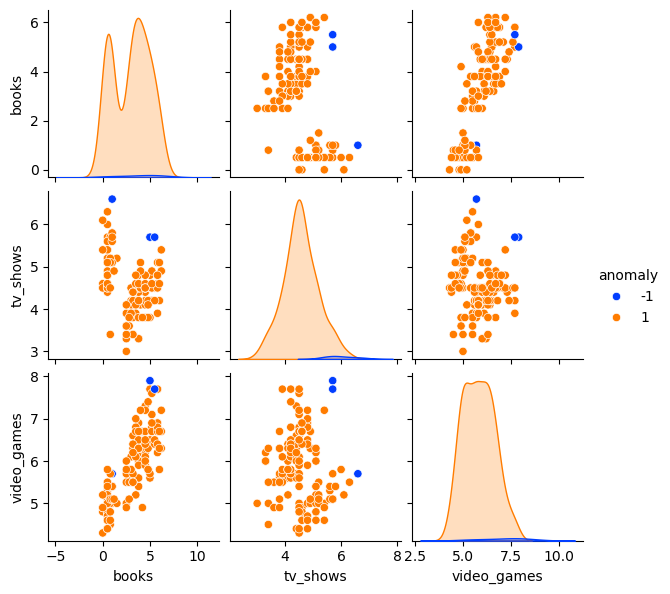

In [32]:
sns.pairplot(df.iloc[:, 1:].drop(columns="anomaly_scores"), hue="anomaly", palette="bright", diag_kind="kde", height=2);

In [22]:
X.head()

,books,tv_shows,video_games
0,0.5,4.6,4.9
1,0.0,4.5,4.8
2,0.5,4.5,5.0
3,3.5,4.5,6.6
4,2.8,3.8,5.6


In [27]:
df.head()

,name,books,tv_shows,video_games,anomaly_scores,anomaly
0,Aaliyah,0.5,4.6,4.9,0.194849,1
1,Abigail,0.0,4.5,4.8,0.119401,1
2,Addison,0.5,4.5,5.0,0.189684,1
3,Adeline,3.5,4.5,6.6,0.206958,1
4,Alana,2.8,3.8,5.6,0.184887,1


In [28]:
df.iloc[:, 1:].drop(columns="anomaly_scores")

,books,tv_shows,video_games,anomaly
0,0.5,4.6,4.9,1
1,0.0,4.5,4.8,1
2,0.5,4.5,5.0,1
3,3.5,4.5,6.6,1
4,2.8,3.8,5.6,1
...,...,...,...,...
145,5.2,4.6,6.9,1
146,6.0,4.6,6.7,1
147,5.5,5.7,7.7,-1
148,0.0,6.1,5.2,1


In [40]:
df.iloc[:, 1:].drop(columns=["anomaly_scores", "anomaly", "anomaly_scores5"])

,books,tv_shows,video_games,anomaly5
0,0.5,4.6,4.9,1
1,0.0,4.5,4.8,1
2,0.5,4.5,5.0,1
3,3.5,4.5,6.6,1
4,2.8,3.8,5.6,1
...,...,...,...,...
145,5.2,4.6,6.9,1
146,6.0,4.6,6.7,1
147,5.5,5.7,7.7,-1
148,0.0,6.1,5.2,-1


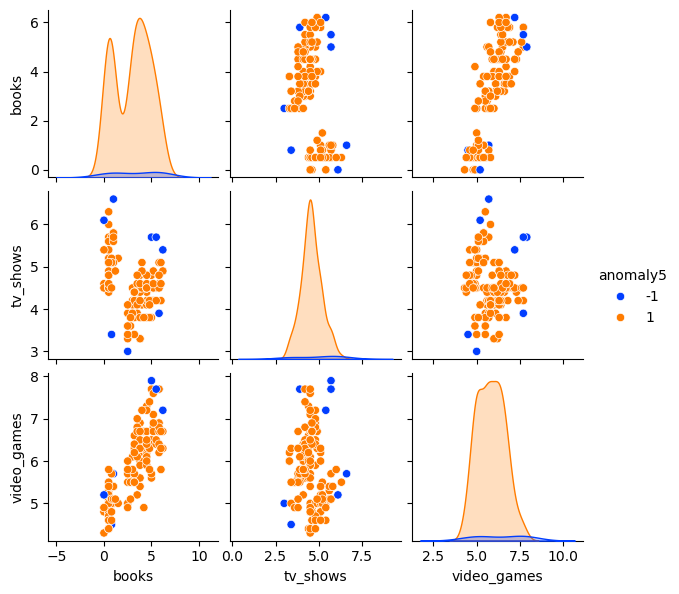

In [44]:
sns.pairplot(df.iloc[:, 1:].drop(columns=["anomaly_scores", "anomaly", "anomaly_scores5"]), hue="anomaly5", palette="bright", diag_kind="kde", height=2);

### d. Tune the Model

In [33]:
model5 = IsolationForest(contamination=0.05)

In [34]:
model5.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,None
,verbose,0
,warm_start,False


In [35]:
df["anomaly_scores5"] = model5.decision_function(X)
df["anomaly5"] = model5.predict(X)

In [36]:
df["anomaly_scores5"] = model5.decision_function(X)
df.sort_values("anomaly_scores5").head()

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores5,anomaly5
110,Octavia,5.0,5.7,7.9,-0.033218,-1,-0.042957,-1
15,Avery,1.0,6.6,5.7,-0.023975,-1,-0.034089,-1
29,Clementine,6.2,5.4,7.2,0.002801,1,-0.028213,-1
37,Elena,0.8,3.4,4.5,0.000091,1,-0.023229,-1
147,Zara,5.5,5.7,7.7,-0.004435,-1,-0.019706,-1


In [38]:
df["anomaly5"] = model5.predict(X)
df.sort_values("anomaly_scores5").head(10)

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores5,anomaly5
110,Octavia,5.0,5.7,7.9,-0.033218,-1,-0.042957,-1
15,Avery,1.0,6.6,5.7,-0.023975,-1,-0.034089,-1
29,Clementine,6.2,5.4,7.2,0.002801,1,-0.028213,-1
37,Elena,0.8,3.4,4.5,0.000091,1,-0.023229,-1
147,Zara,5.5,5.7,7.7,-0.004435,-1,-0.019706,-1
148,Zoe,0.0,6.1,5.2,0.020396,1,-0.010128,-1
58,Hailey,2.5,3.0,5.0,0.013562,1,-0.005729,-1
19,Bianca,5.8,3.9,7.7,0.031045,1,-0.003491,-1
42,Elizabeth,0.0,4.5,4.3,0.041905,1,0.004267,1
129,Sofia,0.5,6.0,5.8,0.052094,1,0.030874,1


## 2. DBSCAN

In [45]:
from sklearn.cluster import DBSCAN

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### a. Fit a DBSCAN Model

In [52]:
def tune_dbscan(data):

    results = []
    
    eps_values = np.arange(.1, 2, .1)
    min_samples_values = np.arange(2, 10, 1)
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            dbscan.fit(data)
            labels = dbscan.labels_
    
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
            n_noise = list(labels).count(-1)
    
            if n_clusters > 1:
                silhouette = silhouette_score(data, labels, metric="euclidean", sample_size=None)
            else:
                silhouette = None
    
            results.append([eps, min_samples, n_clusters, n_noise, silhouette])
    
    dbscan_results = pd.DataFrame(results, columns=["Eps", "Minimum Samples", "Number of Clusters",
                                                   "Number of Noise Points", "Silhouette Score"])
    return dbscan_results

In [53]:
dbscan_results = tune_dbscan(X)
dbscan_results.head()

,Eps,Minimum Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,0.1,2,12,124,-0.438782
1,0.1,3,2,144,-0.483479
2,0.1,4,0,150,NaN
3,0.1,5,0,150,NaN
4,0.1,6,0,150,NaN


In [54]:
dbscan_results.sort_values("Silhouette Score", ascending=False).groupby("Silhouette Score").head(1).head()

,Eps,Minimum Samples,Number of Clusters,Number of Noise Points,Silhouette Score
109,1.4,7,2,0,0.628673
77,1.0,7,2,2,0.550831
66,0.9,4,2,3,0.528540
72,1.0,2,2,1,0.515323
57,0.8,3,2,4,0.497686


In [55]:
dbscan = DBSCAN(eps=1, min_samples=6)

In [56]:
dbscan.fit(X)

,eps,1
,min_samples,6
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [57]:
dbscan.labels_

array([ 0,  0,  0,  1,  1,  1,  1,  1,  0,  1,  1,  0,  0,  0,  0,  0,  1,
        0,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  0,  1,  1,  1,  0,  0,  1,  1,  0,  1,  0,  1,  1,
        1,  1,  1,  1,  1,  0,  1,  1,  1,  0,  0,  0,  1,  1,  1,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0,
        1,  1,  0,  0,  1,  0,  1,  1,  1,  1,  1,  1,  1,  1,  0,  1,  0,
        1,  1,  1,  1,  0,  1,  0,  0, -1,  1,  0,  0,  0,  1,  1,  0,  1,
        1,  1,  1,  0,  0,  0,  1,  1,  1,  1,  0,  0,  0,  1,  0,  1,  1,
        1,  1,  1,  1,  0,  0,  1,  1,  1,  1,  1,  1,  0,  0])

### b. Visualize the Anomalies

In [58]:
df.head()

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores5,anomaly5
0,Aaliyah,0.5,4.6,4.9,0.194849,1,0.161925,1
1,Abigail,0.0,4.5,4.8,0.119401,1,0.076152,1
2,Addison,0.5,4.5,5.0,0.189684,1,0.156366,1
3,Adeline,3.5,4.5,6.6,0.206958,1,0.176545,1
4,Alana,2.8,3.8,5.6,0.184887,1,0.152086,1


In [59]:
df["anomaly_dbscan"] = dbscan.labels_

In [60]:
df.head()

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores5,anomaly5,anomaly_dbscan
0,Aaliyah,0.5,4.6,4.9,0.194849,1,0.161925,1,0
1,Abigail,0.0,4.5,4.8,0.119401,1,0.076152,1,0
2,Addison,0.5,4.5,5.0,0.189684,1,0.156366,1,0
3,Adeline,3.5,4.5,6.6,0.206958,1,0.176545,1,1
4,Alana,2.8,3.8,5.6,0.184887,1,0.152086,1,1


In [61]:
df[df["anomaly_dbscan"] == -1]

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores5,anomaly5,anomaly_dbscan
37,Elena,0.8,3.4,4.5,0.000091,1,-0.023229,-1,-1
110,Octavia,5.0,5.7,7.9,-0.033218,-1,-0.042957,-1,-1


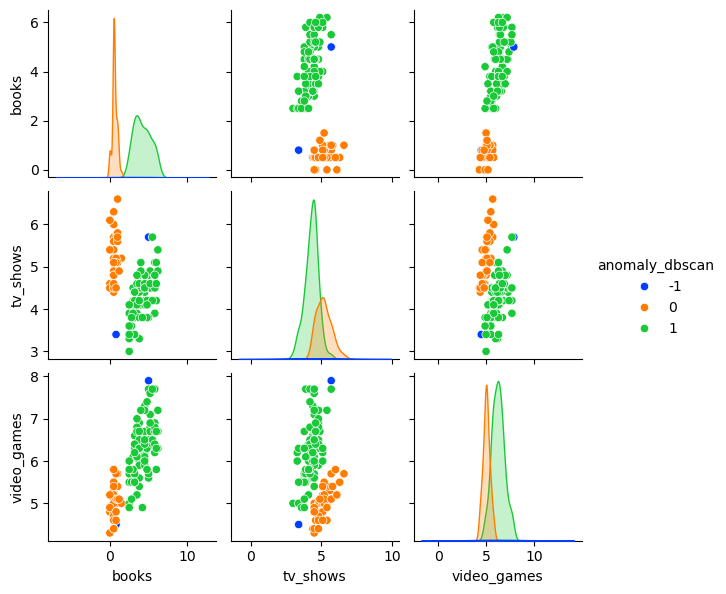

In [64]:
sns.pairplot(df[["books", "tv_shows", "video_games", "anomaly_dbscan"]], hue="anomaly_dbscan", palette="bright", diag_kind="kde", height=2);